In [1]:
import torch, random
from statistics import mean
from cebmf_torch import cEBMF
import matplotlib.pyplot as plt
# ---- config
NUM_RUNS   =20
N, P       = 50, 40
NOISE_STD  = 1.0
MAXIT      = 50
TOL        = 1e-9   # numerical tolerance for strictness

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

def is_strictly_increasing(xs, tol=0.0001):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] + tol for t in range(len(xs)-1))

def is_strictly_decreasing(xs, tol=0.0):
    # xs[t+1] < xs[t] - tol  for all t
    return all(xs[t+1] < xs[t] - tol for t in range(len(xs)-1))

def one_run(seed):
    # reproducibility
    random.seed(seed)
    torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
    u = torch.rand(N, device=device)
    v = torch.rand(P, device=device)
    Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

    model = cEBMF(data=Y, K=5, allow_backfitting=False)
    model.initialise_factors()
    model.fit(maxit=MAXIT)

    loss_hist = model.obj                       # your stored objective = negative ELBO
    return(loss_hist)
 


results=[]

for i in range(NUM_RUNS):
    results.append( one_run(i))
 

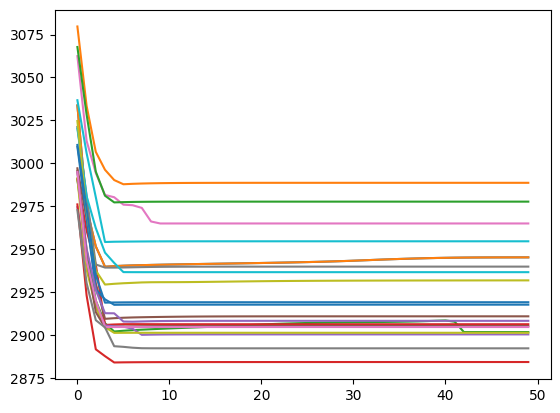

In [2]:
plt.plot(results[0])
for i in range(NUM_RUNS):
    plt.plot(results[i])

In [3]:
def is_strictly_increasing(xs, tol=0.1):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] - tol for t in range(len(xs)-1))

In [4]:
is_strictly_increasing(results[0])

False

In [5]:
h=0

for i in range(NUM_RUNS):
    if (is_strictly_increasing(results[i], tol=0.005))== False:
        print(i)
        h=h+1



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [6]:
(results[6])

[3021.1840209960938,
 2981.2449436187744,
 2941.076089859009,
 2939.286273956299,
 2939.260622024536,
 2939.330686569214,
 2939.442211151123,
 2939.5501022338867,
 2939.6368408203125,
 2939.700595855713,
 2939.745536804199,
 2939.7761154174805,
 2939.796543121338,
 2939.810157775879,
 2939.8192024230957,
 2939.8250160217285,
 2939.8287048339844,
 2939.8311681747437,
 2939.83288025856,
 2939.8339195251465,
 2939.834661960602,
 2939.835054397583,
 2939.8356494903564,
 2939.8355979919434,
 2939.835952758789,
 2939.8358612060547,
 2939.835765838623,
 2939.8357124328613,
 2939.8359184265137,
 2939.835910797119,
 2939.835906982422,
 2939.8359146118164,
 2939.8358840942383,
 2939.8359451293945,
 2939.83597946167,
 2939.8359451293945,
 2939.8359870910645,
 2939.8361473083496,
 2939.836139678955,
 2939.835926055908,
 2939.835922241211,
 2939.835922241211,
 2939.8361282348633,
 2939.835926055908,
 2939.8359146118164,
 2939.8358879089355,
 2939.8361587524414,
 2939.835910797119,
 2939.83589935302